In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.utils import to_categorical
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:

dataset, info = tfds.load('deep_weeds', with_info=True, as_supervised=True)
datos = dataset['train']


C:\Users\abiab\AppData\Local\Temp\ipykernel_3700\1205265430.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class_name', y='count', data=label_counts, palette='colorblind')


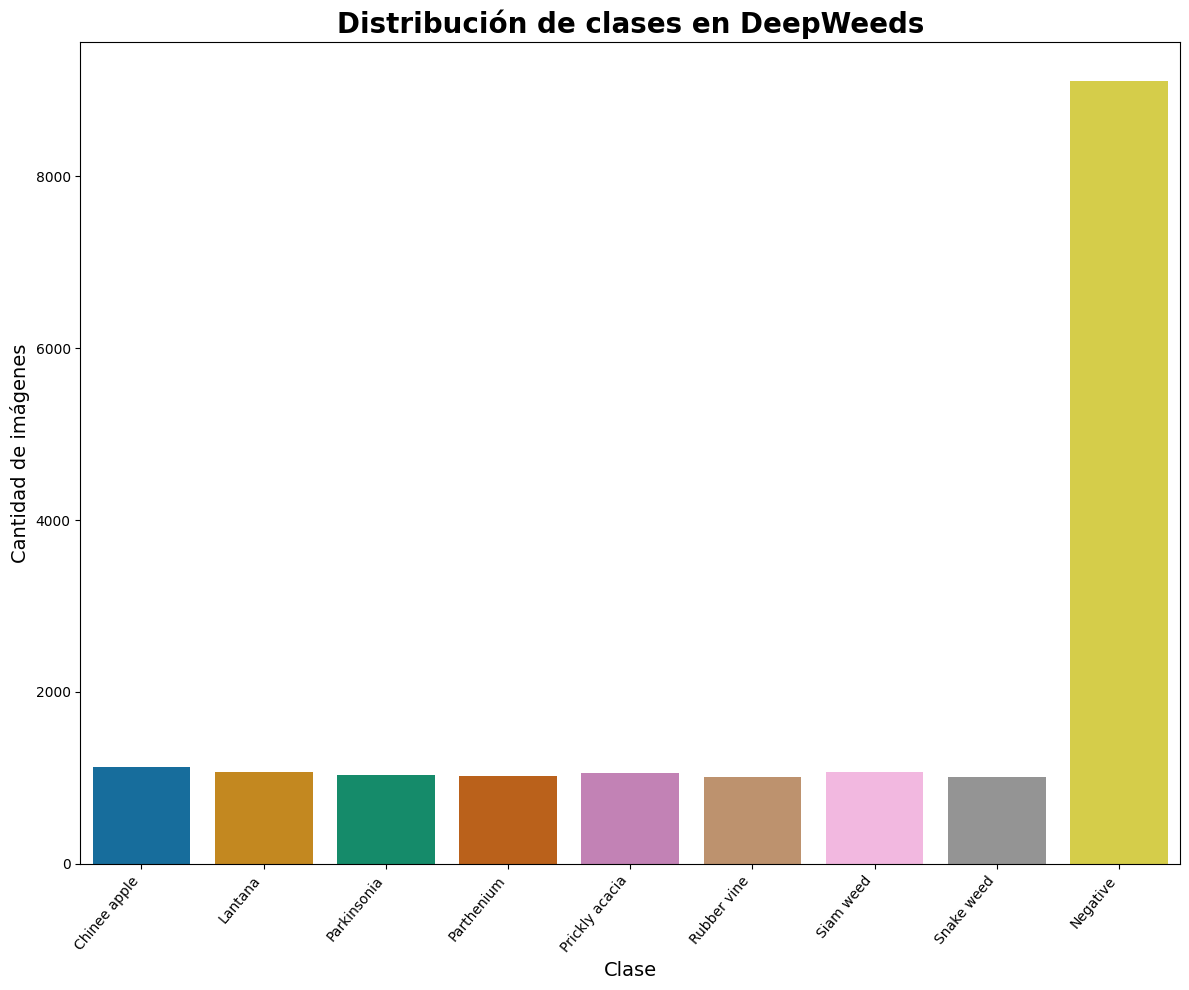

In [18]:
labels = [label.numpy() for _, label in datos]
label_counts = pd.DataFrame({'label': labels})
label_counts = label_counts.groupby('label').size().reset_index(name='count')

class_names = info.features['label'].names
label_counts['class_name'] = label_counts['label'].apply(lambda x: class_names[x])

plt.figure(figsize=(12, 10))
sns.barplot(x='class_name', y='count', data=label_counts, palette='colorblind')

plt.title('Distribución de clases en DeepWeeds', fontsize=20, weight='bold')
plt.xlabel('Clase', fontsize=14)
plt.ylabel('Cantidad de imágenes', fontsize=14)
plt.xticks(rotation=50, ha='right', fontsize=10)

plt.tight_layout()

In [17]:
datos_filtrados = datos.filter(lambda image, label: label != 8)
num_elementos = sum(1 for _ in datos_filtrados)
print(num_elementos)

8403


C:\Users\abiab\AppData\Local\Temp\ipykernel_3700\1012510221.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class_name', y='count', data=label_counts, palette='colorblind')


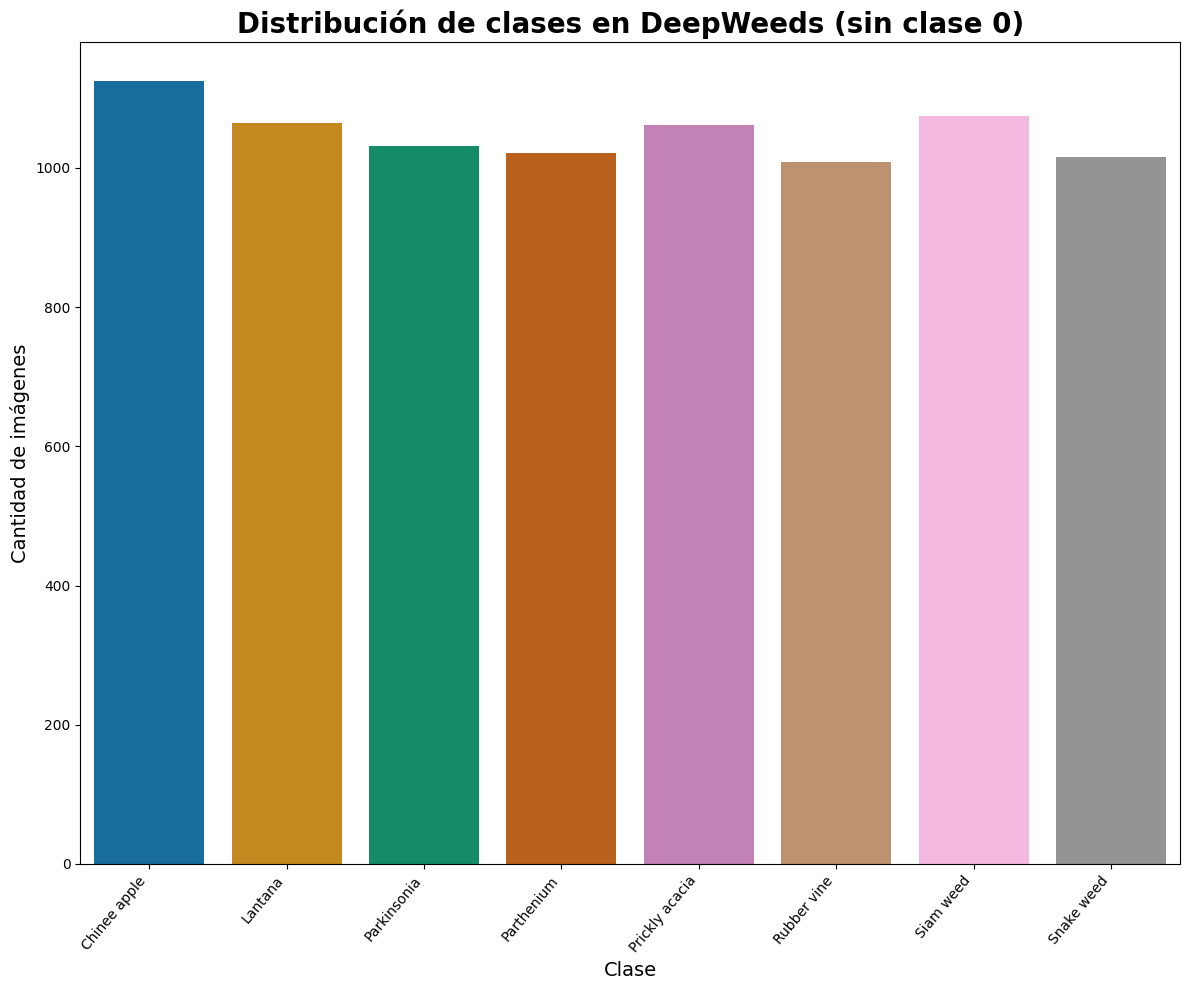

In [5]:
labels = [label.numpy() for _, label in datos_filtrados]
label_counts = pd.DataFrame({'label': labels})
label_counts = label_counts.groupby('label').size().reset_index(name='count')

class_names = info.features['label'].names
label_counts['class_name'] = label_counts['label'].apply(lambda x: class_names[x])

plt.figure(figsize=(12, 10))
sns.barplot(x='class_name', y='count', data=label_counts, palette='colorblind')

plt.title('Distribución de clases en DeepWeeds (sin clase 0)', fontsize=20, weight='bold')
plt.xlabel('Clase', fontsize=14)
plt.ylabel('Cantidad de imágenes', fontsize=14)
plt.xticks(rotation=50, ha='right', fontsize=10)

plt.tight_layout()

In [6]:
def procesar_img(image, label, target_size=(128, 128), to_hsv=True):
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, target_size)
    if to_hsv:
        image = tf.image.rgb_to_hsv(image)
    return image, label

def guardar_datasets(imgs, nombre):
    imagenes = []
    for img in imgs:
        imagenes.append(img.numpy())
    np.save(f"Datos/{nombre}", imagenes)

In [7]:
X_rgb_64 = []

for image, label in tfds.as_numpy(datos_filtrados):
    img, _ = procesar_img(image, label, target_size=(64, 64), to_hsv=False)
    X_rgb_64.append(img)

guardar_datasets(X_rgb_64, 'X_rgb_64')
del X_rgb_64

In [8]:
X_rgb_128 = []

for image, label in tfds.as_numpy(datos_filtrados):
    img, _ =procesar_img(image, label, target_size=(128, 128), to_hsv=False)
    X_rgb_128.append(img)

guardar_datasets(X_rgb_128, 'X_rgb_128')
del X_rgb_128

In [9]:
X_hsv_64 = []

for image, label in tfds.as_numpy(datos_filtrados):
    img, _ =procesar_img(image, label, target_size=(64, 64), to_hsv=True)
    X_hsv_64.append(img)

guardar_datasets(X_hsv_64, 'X_hsv_64')
del X_hsv_64

In [10]:
X_hsv_128 = []

for image, label in tfds.as_numpy(datos_filtrados):
    img, _ =procesar_img(image, label, target_size=(128, 128), to_hsv=True)
    X_hsv_128.append(img)

guardar_datasets(X_hsv_128, 'X_hsv_128')
del X_hsv_128

In [11]:
y = []
for image, label in tfds.as_numpy(datos_filtrados):
    _, label = procesar_img(image, label, target_size=(1, 1), to_hsv=False)
    y.append(label)

y_onehot = np.array(to_categorical(y))
del y

np.save("Datos/y_one_hot", y_onehot)